# 🌾 CropLogic AI — Notebook 03
### Soil Assessment Module
---
**What this notebook does:**
1. Load the preprocessed dataset
2. Detect soil constraints per county (pH, SOC, texture problems)
3. Score and classify each county into a soil health tier
4. Analyse how soil properties correlate with yield
5. Rank states by soil health
6. Visualise everything and save the results

**Input:** `usa_maize_preprocessed.csv`  
**Output:** `soil_assessment.csv` — per-county soil health scores and tiers

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1923',
    'axes.facecolor':   '#0f1923',
    'axes.edgecolor':   '#2a3f52',
    'axes.labelcolor':  '#c8d8e8',
    'text.color':       '#c8d8e8',
    'xtick.color':      '#8aa0b0',
    'ytick.color':      '#8aa0b0',
    'grid.color':       '#1e2e3e',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.size':        11,
})

C = {
    'green':  '#00d4aa',
    'orange': '#ff6b35',
    'blue':   '#4fc3f7',
    'yellow': '#ffd166',
    'purple': '#a78bfa',
    'red':    '#f87171',
}

print('✅ Imports ready')

✅ Imports ready


---
## 1. Load Data

In [2]:
# Load the preprocessed dataset (output of Notebook 01)
df = pd.read_csv('usa_maize_preprocessed.csv')

# Recalculate silt if not already in the file
if 'soil_silt_percent' not in df.columns:
    df['soil_silt_percent'] = (100 - df['soil_clay_percent'] - df['soil_sand_percent']).clip(0)

print('=== DATASET LOADED ===')
print(f'  Rows:     {len(df):,}')
print(f'  Counties: {df.county_id.nunique()}')
print(f'  States:   {df.state.nunique()}')
print(f'  Columns:  {df.shape[1]}')

=== DATASET LOADED ===
  Rows:     62,400
  Counties: 975
  States:   15
  Columns:  18


In [3]:
# Collapse to one row per county by averaging all years.
# Soil properties are stable over time, so the average is a good county-level summary.

SOIL_COLS = ['soil_ph_topsoil', 'soil_soc_percent',
             'soil_clay_percent', 'soil_sand_percent', 'soil_silt_percent']

county_df = (
    df.groupby(['county_id', 'state'])
    .agg(
        mean_yield  = ('yield_kg_ha',       'mean'),
        ph          = ('soil_ph_topsoil',    'mean'),
        soc         = ('soil_soc_percent',   'mean'),
        clay        = ('soil_clay_percent',  'mean'),
        sand        = ('soil_sand_percent',  'mean'),
        silt        = ('soil_silt_percent',  'mean'),
    )
    .reset_index()
)

print(f'✅ County-level summary: {len(county_df)} counties')
display(county_df.head())

✅ County-level summary: 975 counties


,county_id,state,mean_yield,ph,soc,clay,sand,silt
0,COL_001,Colorado,4661.148438,6.734219,1.269531,9.568750,39.964062,50.467188
1,COL_002,Colorado,4835.692187,7.423125,1.585781,13.700000,34.507812,51.792188
2,COL_003,Colorado,5625.640625,6.946719,1.047187,19.401563,46.428125,34.170313
3,COL_004,Colorado,5563.454687,6.870000,1.775781,21.950000,41.371875,36.678125
4,COL_005,Colorado,5738.885938,7.704375,0.855156,17.382812,41.610937,41.006250


---
## 2. Soil Constraint Detection

We flag each county for known soil problems that hurt maize yield.
Each constraint is a binary flag (1 = problem present, 0 = ok).

| Constraint | Threshold | Why it matters |
|---|---|---|
| pH too low (acidic) | pH < 5.8 | Nutrients become unavailable; aluminium toxicity risk |
| pH too high (alkaline) | pH > 7.2 | Iron/manganese deficiency; reduces nutrient uptake |
| Low organic carbon | SOC < 1.5% | Poor soil structure, low water retention, fewer microbes |
| High sand | Sand > 55% | Drains too fast — crops suffer drought stress |
| High clay | Clay > 40% | Compacts easily, poor drainage, hard for roots to penetrate |

In [4]:
# Flag each county for each constraint (1 = has problem, 0 = fine)

county_df['flag_low_ph']   = (county_df['ph']  < 5.8).astype(int)
county_df['flag_high_ph']  = (county_df['ph']  > 7.2).astype(int)
county_df['flag_low_soc']  = (county_df['soc'] < 1.5).astype(int)
county_df['flag_high_sand']= (county_df['sand']> 55.0).astype(int)
county_df['flag_high_clay']= (county_df['clay']> 40.0).astype(int)

# Total number of constraints per county (0 = perfect soil, 5 = worst possible)
flag_cols = ['flag_low_ph', 'flag_high_ph', 'flag_low_soc', 'flag_high_sand', 'flag_high_clay']
county_df['n_constraints'] = county_df[flag_cols].sum(axis=1)

print('=== CONSTRAINT PREVALENCE ===')
for col in flag_cols:
    n = county_df[col].sum()
    pct = n / len(county_df) * 100
    label = col.replace('flag_', '').replace('_', ' ')
    print(f'  {label:<18}: {n:>4} counties ({pct:.1f}%)')

print(f'\n  Counties with 0 constraints: {(county_df["n_constraints"]==0).sum()}')
print(f'  Counties with 1+ constraint: {(county_df["n_constraints"]>=1).sum()}')

=== CONSTRAINT PREVALENCE ===
  low ph            :   29 counties (3.0%)
  high ph           :   30 counties (3.1%)
  low soc           :   90 counties (9.2%)
  high sand         :    7 counties (0.7%)
  high clay         :    3 counties (0.3%)

  Counties with 0 constraints: 837
  Counties with 1+ constraint: 138


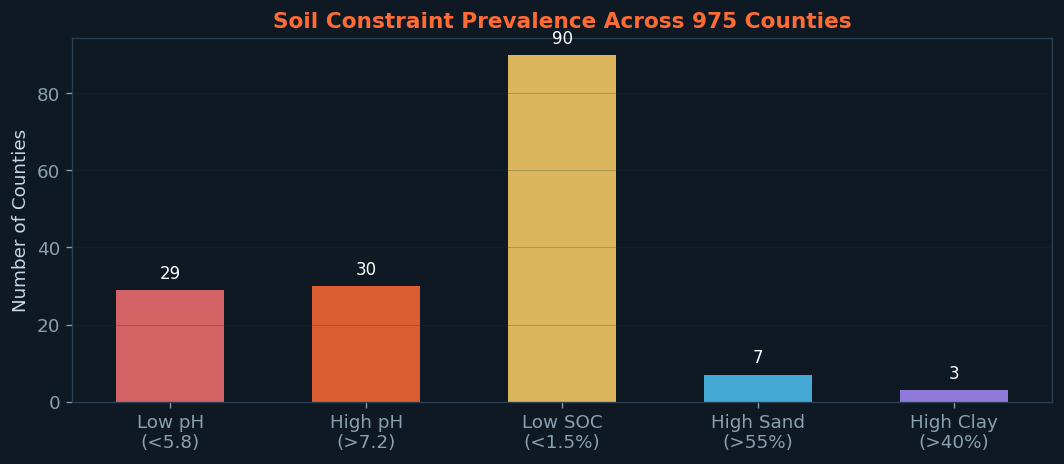

In [5]:
# Chart 1 — How many counties have each constraint?

constraint_counts = county_df[flag_cols].sum()
constraint_labels = ['Low pH\n(<5.8)', 'High pH\n(>7.2)', 'Low SOC\n(<1.5%)',
                     'High Sand\n(>55%)', 'High Clay\n(>40%)']
bar_colors = [C['red'], C['orange'], C['yellow'], C['blue'], C['purple']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(constraint_labels, constraint_counts.values, color=bar_colors, alpha=0.85, width=0.55)

for bar, val in zip(bars, constraint_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=10, color='white')

ax.set_ylabel('Number of Counties')
ax.set_title('Soil Constraint Prevalence Across 975 Counties',
             color=C['orange'], fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_soil_constraints.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 3. Soil Health Score & Tier Classification

We compute a **soil health score** (0–100) for each county by combining three components:

| Component | What it measures | Weight |
|---|---|---|
| pH score | How close pH is to the ideal 6.5 | 33% |
| SOC score | How adequate soil organic carbon is | 33% |
| Texture score | Balance of clay/silt vs sand | 34% |

Then we classify each county into a **health tier**:

| Score | Tier |
|---|---|
| ≥ 70 | 🟢 Good |
| 50–69 | 🟡 Moderate |
| < 50 | 🔴 Poor |

In [6]:
# ── pH Score ───────────────────────────────────────────────────────────
# pH of 6.5 is ideal for maize. The further from 6.5, the lower the score.
# We map the deviation to a 0-100 scale where 0 deviation = score 100.

ph_deviation = abs(county_df['ph'] - 6.5)           # 0 = perfect, higher = worse
ph_score     = (1 - ph_deviation / ph_deviation.max()) * 100

# ── SOC Score ──────────────────────────────────────────────────────────
# Soil organic carbon above 2% is good for maize. We scale 0→2% as 0→100.
# Counties with SOC >= 2% all get 100.

soc_score = (county_df['soc'] / 2.0).clip(0, 1) * 100

# ── Texture Score ──────────────────────────────────────────────────────
# Clay loam / loam is ideal: good water retention without compaction.
# We penalise extremes: very high sand (drains too fast) or very high clay (compacts).

sand_penalty = (county_df['sand'] / 100) ** 2   # high sand = bigger penalty
clay_penalty = (county_df['clay'] / 100) ** 2   # high clay = bigger penalty
texture_score = (1 - sand_penalty - clay_penalty).clip(0, 1) * 100

# ── Combined Soil Health Score ─────────────────────────────────────────
county_df['soil_health_score'] = (ph_score * 0.33 + soc_score * 0.33 + texture_score * 0.34)

print('✅ Soil health scores computed')
print(f'   Mean score:   {county_df["soil_health_score"].mean():.1f}')
print(f'   Min score:    {county_df["soil_health_score"].min():.1f}')
print(f'   Max score:    {county_df["soil_health_score"].max():.1f}')

✅ Soil health scores computed
   Mean score:   84.1
   Min score:    42.5
   Max score:    96.5


In [7]:
# Classify each county into a health tier based on their score

def assign_tier(score):
    if score >= 70:
        return 'Good'
    elif score >= 50:
        return 'Moderate'
    else:
        return 'Poor'

county_df['soil_tier'] = county_df['soil_health_score'].apply(assign_tier)

tier_counts = county_df['soil_tier'].value_counts()
print('=== SOIL HEALTH TIER DISTRIBUTION ===')
for tier, count in tier_counts.items():
    pct = count / len(county_df) * 100
    print(f'  {tier:<12}: {count:>4} counties ({pct:.1f}%)')

=== SOIL HEALTH TIER DISTRIBUTION ===
  Good        :  913 counties (93.6%)
  Moderate    :   57 counties (5.8%)
  Poor        :    5 counties (0.5%)


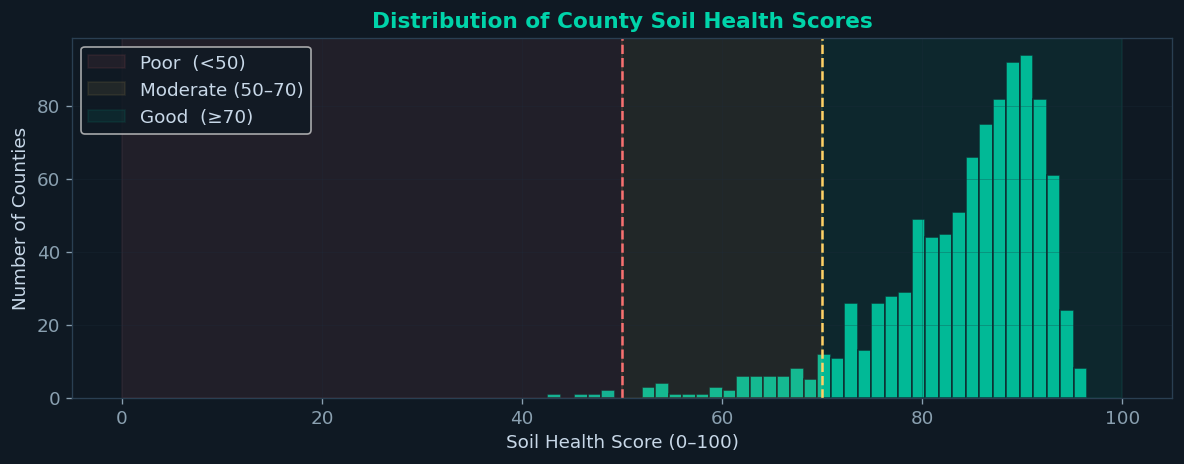

In [8]:
# Chart 2 — Soil health score distribution with tier bands

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(county_df['soil_health_score'], bins=40,
        color=C['green'], edgecolor='#0f1923', alpha=0.85)

# Shade tier regions
ax.axvspan(0,  50, alpha=0.08, color=C['red'],    label='Poor  (<50)')
ax.axvspan(50, 70, alpha=0.08, color=C['yellow'], label='Moderate (50–70)')
ax.axvspan(70, 100,alpha=0.08, color=C['green'],  label='Good  (≥70)')

# Tier boundary lines
ax.axvline(50, color=C['red'],    linewidth=1.5, ls='--')
ax.axvline(70, color=C['yellow'], linewidth=1.5, ls='--')

ax.set_xlabel('Soil Health Score (0–100)')
ax.set_ylabel('Number of Counties')
ax.set_title('Distribution of County Soil Health Scores',
             color=C['green'], fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_soil_health_dist.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

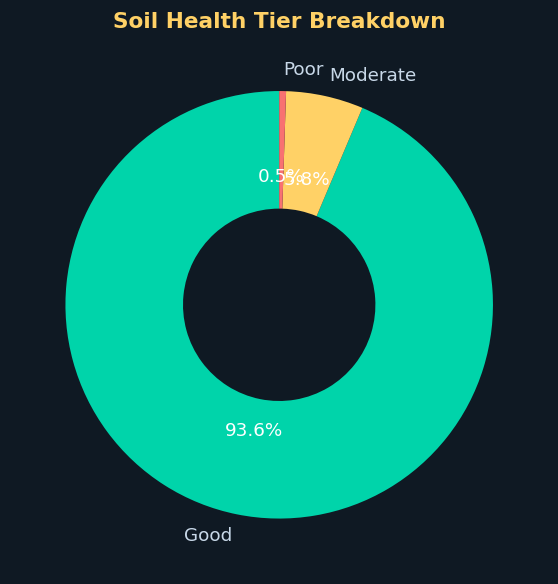

In [9]:
# Chart 3 — Tier breakdown as a donut chart

tier_order  = ['Good', 'Moderate', 'Poor']
tier_colors = [C['green'], C['yellow'], C['red']]
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    tier_vals, labels=tier_order, colors=tier_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55),         # donut hole
    textprops=dict(color='#c8d8e8')
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')

ax.set_title('Soil Health Tier Breakdown',
             color=C['yellow'], fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_soil_tier_pie.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 4. Soil–Yield Correlation Analysis

How strongly does each soil property correlate with maize yield?  
We detrend yield first (remove the time trend) so that 60 years of technology improvement doesn't dominate.

In [10]:
# Detrend yield: subtract the national average for each year.
# This removes the upward technology trend, leaving only climate/soil-driven variation.

df['yield_detrended'] = (
    df['yield_kg_ha'] - df.groupby('year')['yield_kg_ha'].transform('mean')
)

print('✅ Yield detrended')
print(f'   Detrended mean (should be ~0): {df["yield_detrended"].mean():.2f}')

✅ Yield detrended
   Detrended mean (should be ~0): 0.00


In [11]:
# Compute Pearson correlation between each soil variable and detrended yield

soil_vars = {
    'soil_ph_topsoil':  'Soil pH',
    'soil_soc_percent': 'Organic Carbon (SOC %)',
    'soil_clay_percent':'Clay %',
    'soil_sand_percent':'Sand %',
    'soil_silt_percent':'Silt %',
}

print('=== SOIL vs DETRENDED YIELD CORRELATIONS ===')
corr_results = {}
for col, label in soil_vars.items():
    r = df[[col, 'yield_detrended']].corr().iloc[0, 1]
    corr_results[label] = r
    direction = '▲' if r > 0 else '▼'
    print(f'  {direction} {label:<30}: r = {r:+.3f}')

=== SOIL vs DETRENDED YIELD CORRELATIONS ===
  ▼ Soil pH                       : r = -0.200
  ▲ Organic Carbon (SOC %)        : r = +0.221
  ▲ Clay %                        : r = +0.032
  ▼ Sand %                        : r = -0.311
  ▲ Silt %                        : r = +0.278


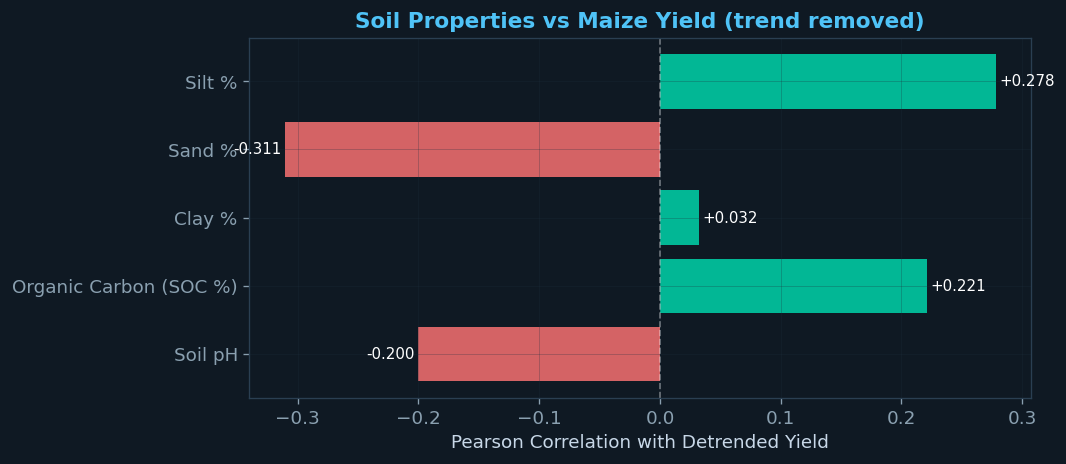

In [12]:
# Chart 4 — Soil variable correlations with detrended yield

labels = list(corr_results.keys())
values = list(corr_results.values())
colors = [C['green'] if v > 0 else C['red'] for v in values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=colors, alpha=0.85)
ax.axvline(0, color='white', lw=1, ls='--', alpha=0.4)

for bar, val in zip(bars, values):
    ax.text(val + 0.003 if val > 0 else val - 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', fontsize=9,
            ha='left' if val > 0 else 'right', color='white')

ax.set_xlabel('Pearson Correlation with Detrended Yield')
ax.set_title('Soil Properties vs Maize Yield (trend removed)',
             color=C['blue'], fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_soil_yield_corr.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

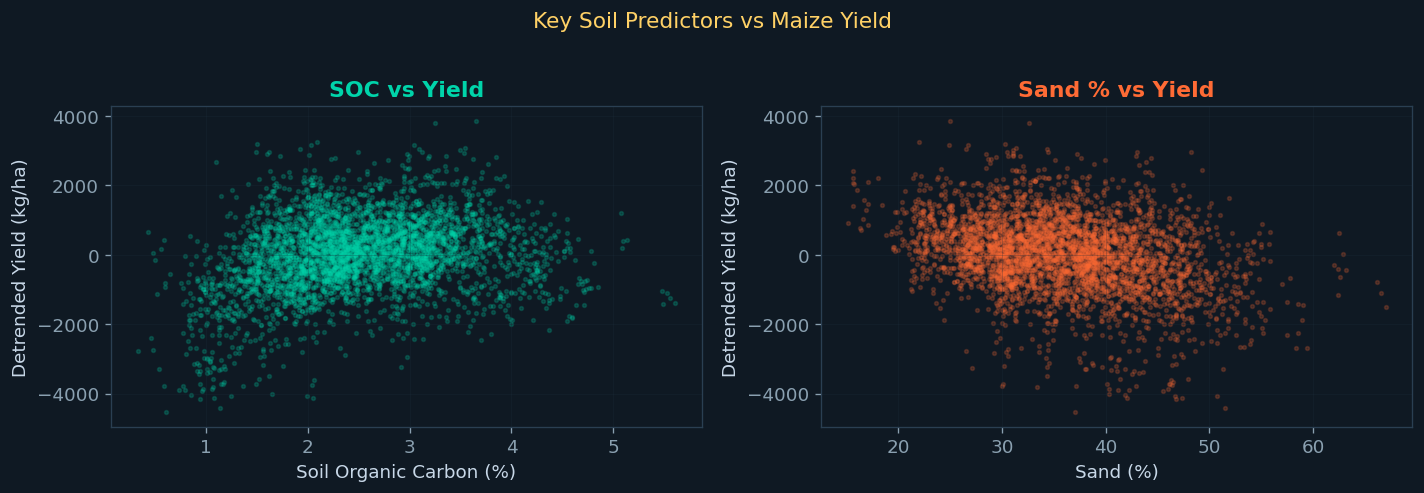

In [13]:
# Chart 5 — Scatter: SOC vs yield (SOC is typically the strongest soil predictor)

sample = df.sample(4000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SOC vs detrended yield
axes[0].scatter(sample['soil_soc_percent'], sample['yield_detrended'],
                alpha=0.2, s=5, color=C['green'])
axes[0].set_xlabel('Soil Organic Carbon (%)')
axes[0].set_ylabel('Detrended Yield (kg/ha)')
axes[0].set_title('SOC vs Yield', color=C['green'], fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Sand vs detrended yield
axes[1].scatter(sample['soil_sand_percent'], sample['yield_detrended'],
                alpha=0.2, s=5, color=C['orange'])
axes[1].set_xlabel('Sand (%)')
axes[1].set_ylabel('Detrended Yield (kg/ha)')
axes[1].set_title('Sand % vs Yield', color=C['orange'], fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Key Soil Predictors vs Maize Yield',
             color=C['yellow'], fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_soil_scatter.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 5. Yield by Soil Tier

Do counties with better soil health actually produce more maize? Let's verify.

In [14]:
# Compare mean yield across the three soil health tiers

tier_yield = county_df.groupby('soil_tier')['mean_yield'].agg(['mean', 'std', 'count'])
tier_yield.columns = ['Mean Yield (kg/ha)', 'Std', 'Counties']
tier_yield = tier_yield.loc[['Good', 'Moderate', 'Poor']]  # fix display order

print('=== MEAN YIELD BY SOIL HEALTH TIER ===')
print(tier_yield.round(1).to_string())

=== MEAN YIELD BY SOIL HEALTH TIER ===
           Mean Yield (kg/ha)     Std  Counties
soil_tier                                      
Good                   6916.7   877.7       913
Moderate               5681.4  1016.8        57
Poor                   5152.9   818.7         5


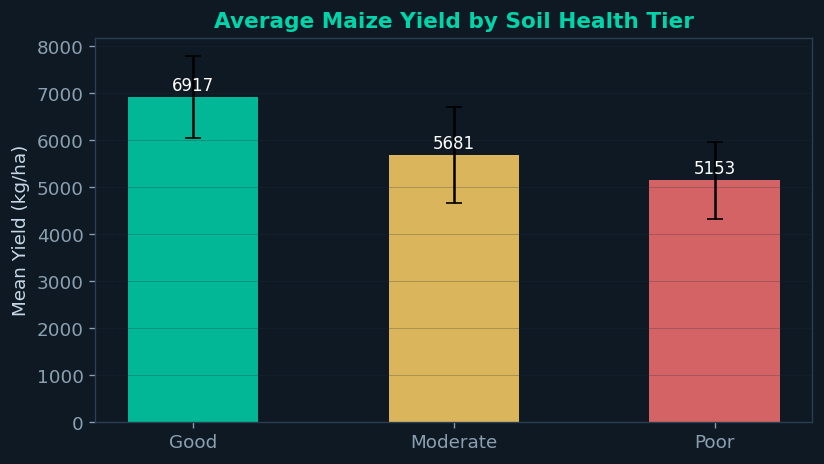

In [15]:
# Chart 6 — Mean yield by soil tier (with error bars for spread)

tiers  = ['Good', 'Moderate', 'Poor']
means  = [tier_yield.loc[t, 'Mean Yield (kg/ha)'] for t in tiers]
stds   = [tier_yield.loc[t, 'Std'] for t in tiers]
colors = [C['green'], C['yellow'], C['red']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tiers, means, color=colors, alpha=0.85,
              yerr=stds, capsize=5, error_kw={'color': 'white', 'linewidth': 1.5},
              width=0.5)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, color='white')

ax.set_ylabel('Mean Yield (kg/ha)')
ax.set_title('Average Maize Yield by Soil Health Tier',
             color=C['green'], fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_yield_by_tier.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 6. State Rankings by Soil Health

In [16]:
# Average soil health score per state (across all counties in that state)

state_ranking = (
    county_df.groupby('state')
    .agg(
        avg_soil_score = ('soil_health_score', 'mean'),
        avg_yield      = ('mean_yield',         'mean'),
        n_counties     = ('county_id',           'count'),
        pct_good       = ('soil_tier',           lambda x: (x == 'Good').mean() * 100),
        pct_poor       = ('soil_tier',           lambda x: (x == 'Poor').mean() * 100),
    )
    .sort_values('avg_soil_score', ascending=False)
    .round(1)
)

print('=== STATE RANKINGS BY SOIL HEALTH SCORE ===')
print(state_ranking.to_string())

=== STATE RANKINGS BY SOIL HEALTH SCORE ===
              avg_soil_score  avg_yield  n_counties  pct_good  pct_poor
state                                                                  
Iowa                    89.1     7491.6          94     100.0       0.0
Indiana                 88.7     7382.7          88     100.0       0.0
Illinois                88.4     7800.1          96     100.0       0.0
Wisconsin               87.4     6806.4          60     100.0       0.0
Ohio                    86.7     7030.8          82      98.8       0.0
Minnesota               86.3     7118.8          80     100.0       0.0
Michigan                84.3     6645.7          55     100.0       0.0
Nebraska                84.1     7571.3          85      96.5       0.0
South Dakota            83.1     6301.4          55     100.0       0.0
North Dakota            82.5     5727.0          45      95.6       0.0
Pennsylvania            81.6     6439.9          40      87.5       0.0
Missouri            

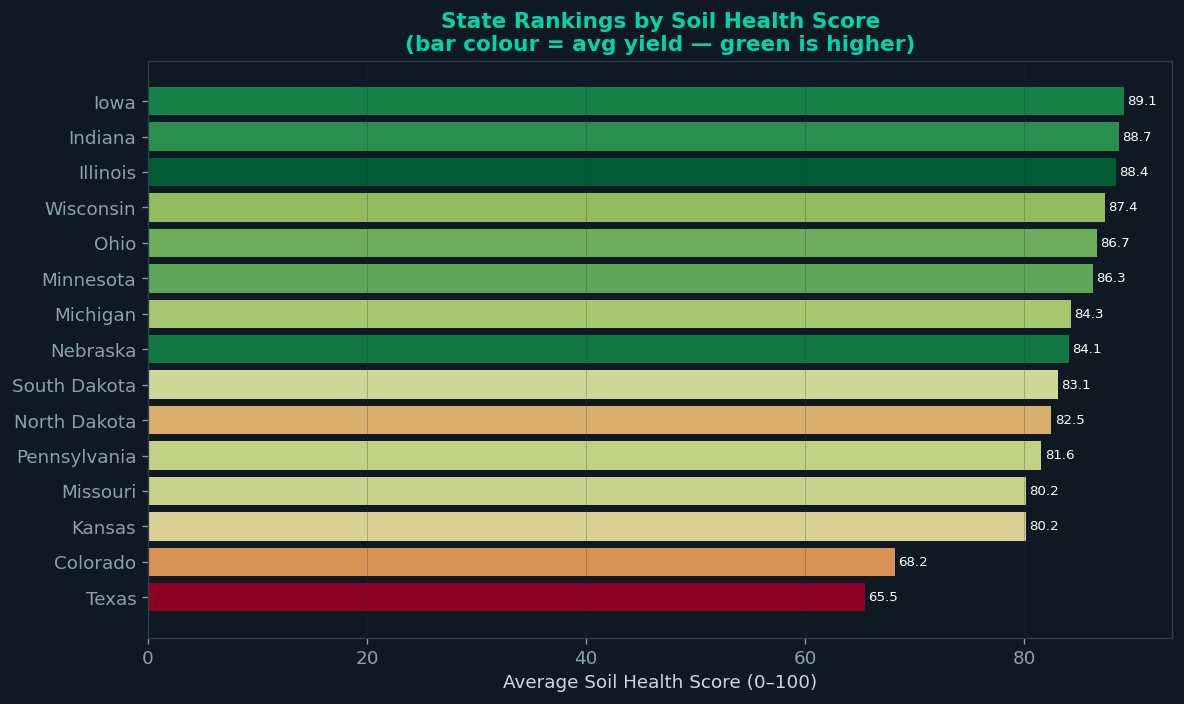

In [17]:
# Chart 7 — State ranking bar chart (coloured by avg yield)

fig, ax = plt.subplots(figsize=(10, 6))

# Colour bars by their average yield (green = high yield, red = low yield)
norm_yield = (state_ranking['avg_yield'] - state_ranking['avg_yield'].min()) / \
             (state_ranking['avg_yield'].max() - state_ranking['avg_yield'].min())
bar_colors = plt.cm.RdYlGn(norm_yield.values)  # red-yellow-green colormap

bars = ax.barh(state_ranking.index[::-1],
               state_ranking['avg_soil_score'][::-1],
               color=bar_colors[::-1], alpha=0.85)

for bar, val in zip(bars, state_ranking['avg_soil_score'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=8, color='white')

ax.set_xlabel('Average Soil Health Score (0–100)')
ax.set_title('State Rankings by Soil Health Score\n(bar colour = avg yield — green is higher)',
             color=C['green'], fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_state_soil_ranking.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

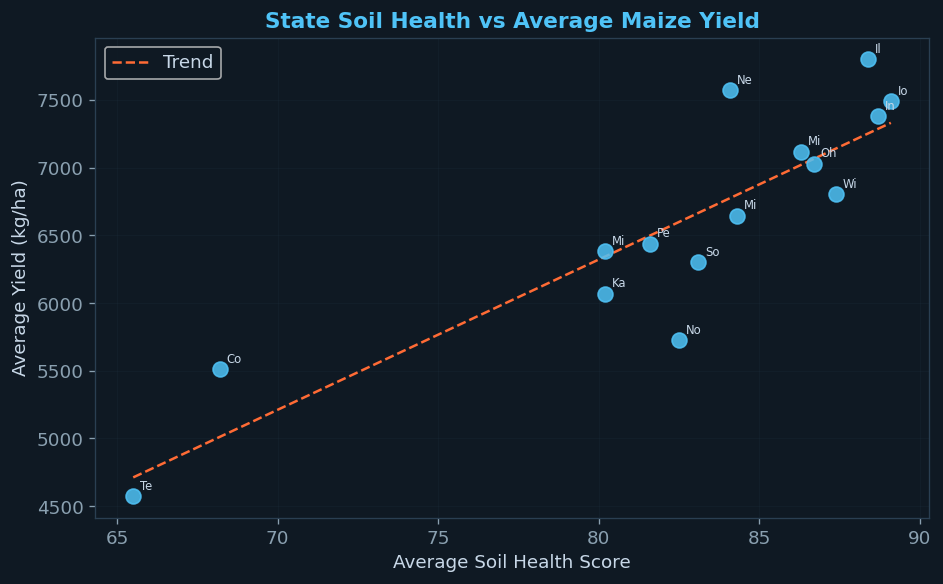

In [18]:
# Chart 8 — Scatter: state-level soil score vs average yield
# Confirms whether better soil → higher yield at the state level

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(state_ranking['avg_soil_score'], state_ranking['avg_yield'],
           s=80, color=C['blue'], alpha=0.85, zorder=3)

# Label each state point
for state, row in state_ranking.iterrows():
    ax.annotate(state[:2],  # first 2 letters of state name
                (row['avg_soil_score'], row['avg_yield']),
                fontsize=7, color='#c8d8e8',
                xytext=(4, 4), textcoords='offset points')

# Trend line
z = np.polyfit(state_ranking['avg_soil_score'], state_ranking['avg_yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(state_ranking['avg_soil_score'].min(),
                     state_ranking['avg_soil_score'].max(), 100)
ax.plot(x_line, p(x_line), color=C['orange'], linewidth=1.5, ls='--', label='Trend')

ax.set_xlabel('Average Soil Health Score')
ax.set_ylabel('Average Yield (kg/ha)')
ax.set_title('State Soil Health vs Average Maize Yield',
             color=C['blue'], fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_soil_vs_yield_state.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 7. Save Results

In [19]:
# Save the county-level soil assessment results
county_df.to_csv('soil_assessment.csv', index=False)

print('✅ Saved → soil_assessment.csv')
print(f'   Rows:    {len(county_df)} counties')
print(f'   Columns: {county_df.shape[1]}')
print()

# Quick summary of what's in the file
print('=== COLUMN SUMMARY ===')
for col in county_df.columns:
    print(f'  {col}')

print()
print('Next step → CropAI-04: Pest Detection')

✅ Saved → soil_assessment.csv
   Rows:    975 counties
   Columns: 16

=== COLUMN SUMMARY ===
  county_id
  state
  mean_yield
  ph
  soc
  clay
  sand
  silt
  flag_low_ph
  flag_high_ph
  flag_low_soc
  flag_high_sand
  flag_high_clay
  n_constraints
  soil_health_score
  soil_tier

Next step → CropAI-04: Pest Detection


---
## ✅ Notebook 03 Complete

| Step | What we did | Output |
|---|---|---|
| Load | Preprocessed dataset, collapsed to county averages | 975 county rows |
| Constraints | Flagged 5 soil problems per county | `n_constraints` column |
| Health Score | Scored 0–100 from pH + SOC + texture | `soil_health_score` column |
| Tiers | Classified counties: Good / Moderate / Poor | `soil_tier` column |
| Yield Correlation | Compared each soil variable against detrended yield | Correlation table + charts |
| State Rankings | Ranked 15 states by average soil health score | Summary table + chart |
| Plots | 8 charts saved as PNGs | `fig_soil_*.png` |
| Save | County-level soil assessment | `soil_assessment.csv` |

**Next → CropAI-04: Pest Detection with EfficientNetB0**